# Voltage Source Simulation
This is a tutorial shows you how to create a machine model and run a voltage source simulation.
A simple current driven simulation was already shown in the [pyleecan_api.ipynp](https://github.com/ttz-emo/pyemmo/blob/master/tutorials/pyleecan_api.ipynb) tutorial.

The notebook related to this tutorial is available on [GitHub](https://github.com/ttz-emo/pyemmo/blob/master/tutorials/voltage_source_simulation.ipynb).

## 1. Create a ONELAB Model from a Pyleecan Machine

Frist we need to create a ONELAB Model using the PyEMMO-Pyleecan-API.

In [22]:
# Load the machine
from __future__ import annotations

import logging
from os.path import join

from pyleecan.definitions import DATA_DIR
from pyleecan.Functions.load import load

from pyemmo.api.pyleecan import main as pyleecan_api
from pyemmo.definitions import RESULT_DIR

IPMSM_A = load(join(DATA_DIR, "Machine", "Toyota_Prius.json"))

# you can set the output verbosity of the model creation using the pyemmo logger.
# The logging module by default implements DEBUG, INFO, WARNING, ERROR, FATAL log
# levels, which are simply constants for integer levels, e.g. logging.DEBUG == 10
# You can use evel(logging.DEBUG -1) to trigger extended debugging, which shows
# additional information in plots and opens the Gmsh GUI at different levels in the
# model creation.
logging.getLogger("pyemmo").setLevel(logging.INFO)

# Run the main function of the pyleecan api:
pyemmo_script = pyleecan_api.main(
    pyleecan_machine=IPMSM_A,
    model_dir=join(RESULT_DIR, "Toyota_Prius_ONELAB"),  # path for the model files
    use_gui=False,  # select if you want to open the final model in Gmsh.
    gmsh="",  # optional gmsh executable.
    # If use_gui is True, pyemmo will try to find a executable on your computer.
    getdp="",  # optional getdp executable. For simulation in the GUI.
)

WARNING - pyemmo.api.pyleecan.build_pyemmo_material - Material 'Copper1' used without magnetic properties. Replacing it with PYLEECAN default material 'Copper2'
INFO - pyemmo.api.json.json - PyEMMO API started on 2026-04-10 11:35:46
INFO - pyemmo.api.json.json - Creating complete model from segmented input...
INFO - pyemmo.api.json.create_airgaps - Stator airgap missing from surfaces. Starting airgap creation.
INFO - pyemmo.api.json.create_airgaps - Creating air closing surface for stator airgap interface.
INFO - pyemmo.api.json.create_airgaps - Creating airgap surface for stator
INFO - pyemmo.api.json.create_airgaps - Setting stator airgap mesh size to band height 0.000150 m
INFO - pyemmo.api.json.create_airgaps - Rotor airgap missing from surfaces. Starting airgap creation.
INFO - pyemmo.api.json.create_airgaps - Creating airgap surface for rotor
INFO - pyemmo.api.json.create_airgaps - Setting rotor airgap mesh size to band height 0.000300 m
INFO - pyemmo.api.json.json - Fixing mesh 

## 2. Setup and run a simple voltage source simulation in ONELAB 

After creating a machine model you can start a simulation in the GUI by adjusting the parameters and clicking the "Run" button.
Or you can use the `run_simulation` function and start a simulation from Python as a subprocess.
Therefore you can specify the same parameters you find in GUI using a parameter dictionary like in the example below (``param_dict``).
You can find all adjustable constants and parameters in the [documentation](https://ttz-emo.thws.de/fileadmin/ttz-emo/pyemmo_doc/source/gen/pyemmo.script.script.html#onelab-model-constants) under **ONELAB Model Constants** and **ONELAB Model Parameters**.

Additionally you can find more information on the ONELAB interface and how to setup and use model parameters on this [ONELAB Wiki page](https://gitlab.onelab.info/doc/tutorials/-/wikis/ONELAB-syntax-for-Gmsh-and-GetDP).


In [23]:
from pyemmo.functions.run_onelab import run_simulation, find_getdp

# Simulation parameters
n = 1500  # rpm
U_amp = 100  # V
phase = 60  # degree, 3 phase system initial phase shift
# You can calculate the winding resistance analytically from Pyleecan:
R_S = IPMSM_A.stator.comp_resistance_wind(T=20)
print(f"Analytical stator winding resistance is {R_S*1e3:.2f} mOhm")
# But we use a higher measured value from literature to speed up settling process
R_S = 0.069  # stator phase resistance in Ohm from literature

# for the transient simulation setup you need to specify the initial and final rotor
# position, as well as the angular step in mechanical degrees.
# Using the speed, GetDP calculates the time step and end time of the simulation.
nbr_stator_periods = 6
end_pos = 360 / IPMSM_A.get_pole_pair_number() * nbr_stator_periods
nbr_steps = 16  # number of steps for one electrical period
angular_step = 360 / 4 / nbr_steps  # mechanical step (to calculate time step)
res_id = "voltage_source"  # result ID (will be the name of the results subfolder)

# create param dict for simulation
# See `pyemmo.functions.run_onelab.run_simulation` for details
param_dict = {
    "getdp": {
        # We need to specify a getdp.exe path! `find_getdp` will search your system path
        # for getdp. If you don't have installed ONELAB (GetDP and Gmsh), you will need
        # to download the (standalone) executables from: https://onelab.info/
        # You can specify the path to getdp.exe as string here if its not on your `path`
        "exe": find_getdp(),
        "verbosity level": 3,  # ONELAB command line output verbosity [1-5, 99]
        # Mechanical Parameters
        "RPM": n,  # speed in rpm
        "initrotor_pos": 0.0,  # initial rotor position in mech. degree
        "d_theta": angular_step,  # angular step in degree
        "finalrotor_pos": end_pos,  # final rotor position in mech. degrees
        # Electrical / source parameters
        "Flag_SrcType_Stator": 2,  # Stator source type: 2 = voltage source
        "Flag_Cir": 0,  # No circuit -> direct voltage over winding phase
        "VV": U_amp,  # voltage amplitude
        "pA_deg": phase,  # phase offset for source with Sin
        "R_S": R_S,  # stator phase resistance in Ohm
        "Flag_Relaxation": 1,  # use relaxation function for source voltage
        "NbTrelax": 2,  # number of stator periods to apply voltage relaxation
        # Analysis parameters
        "Flag_AnalysisType": 1,  # 1 = transient (0 = static)
        "Flag_EC_Magnets": 0,  # no eddy currents in magnets
        "Flag_Debug": 1,  # show debug information
        "stop_criterion": 1e-8,  # residuum threshold
        # Results parameters
        "res": pyemmo_script.results_path,  # result folder
        "ResId": res_id,  # simulation id = results subfolder name (in results folder)
        "Flag_ClearResults": 1,  # remove previous results (if present)
        "Flag_PrintFields": 0,  # show field results in GUI
        # "msh": "",  # path to predefined mesh file
    },
    "pro": pyemmo_script.pro_file_path,  # machine .pro file
    # Gmsh executable and Parameters
    "gmsh": {
        "exe": "",  # Here you can give the path to a gmsh.exe. If nothing given, PyEMMO
        # will try to find Gmsh. This usually uses Gmsh provided with the gmsh python
        # package: https://pypi.org/project/gmsh/
        "gmsf": 2,  # gmsh global mesh size factor (multiplier for point mesh sizes).
        # > 1 = coarser mesh (used here for faster calculation)
    },
    "info": f"Simple voltage driven simulation with {int(U_amp)} V peak phase voltage at "
    f"{n}rpm for {nbr_stator_periods} periods with 2 periods of relaxation",
    # Here you could specify additional postoperations to be executed AFTER the solution.
    # These can be defined in the PyEMMO `Script` object. See Pyleecan API Tutorial.
    "PostOp": [],  # "GetBOnRadius" - "Get_LocalFields_Post"
}

Analytical stator winding resistance is 35.95 mOhm


In [24]:
# Run the simulation
results = run_simulation(param_dict)

WARNING - pyemmo.functions.run_onelab - Removing previous results from folder: C:/Users/ganser/AppData/Roaming/pyemmo/Results/Toyota_Prius_ONELAB/res_Toyota_Prius\voltage_source
INFO - pyemmo.functions.run_onelab - Running simulation for result-ID 'voltage_source'
INFO - pyemmo.functions.run_onelab - 
INFO - pyemmo.functions.run_onelab - (.venv_312) d:\pyemmo\tutorials>echo on 
INFO - pyemmo.functions.run_onelab - 
INFO - pyemmo.functions.run_onelab - (.venv_312) d:\pyemmo\tutorials>echo d:\pyemmo\.venv_312\Scripts\gmsh.bat 
INFO - pyemmo.functions.run_onelab - d:\pyemmo\.venv_312\Scripts\gmsh.bat
INFO - pyemmo.functions.run_onelab - 
INFO - pyemmo.functions.run_onelab - (.venv_312) d:\pyemmo\tutorials>where python 
INFO - pyemmo.functions.run_onelab - d:\pyemmo\.venv_312\Scripts\python.exe
INFO - pyemmo.functions.run_onelab - C:\Users\ganser\AppData\Local\Programs\Python\Python312\python.exe
INFO - pyemmo.functions.run_onelab - 
INFO - pyemmo.functions.run_onelab - (.venv_312) d:\pyem

After the simulation has finished, PyEMMO automatically imports the standard global result values using `pyemmo.functions.import_results.main` function and output the results in a dictionary structure.
Here we store this output in the variable `results`.

Using `print` or `pprint` (pretty-print) we can show the dictionary keys.

Depended on the simulation parameters defined in `param_dict["getdp"]`, not all of the keys must contain result data.

In [29]:
from pprint import pprint

print("Result quantities:")
pprint(list(results.keys()))
print("\nVoltage result phase indices:")
pprint(list(results["voltage"].keys()))

Result quantities:
['time',
 'rotorPos',
 'current',
 'voltage',
 'torque',
 'torque_vw',
 'rotor torque',
 'stator torque',
 'flux',
 'inducedVoltage']

Voltage result phase indices:
['a', 'b', 'c']


The simple voltage source simulation creates a 3 phase sine voltage excitation over each of the winding phase objects.
Where one winding object consists of a voltage source describing the induced voltage $U_i$ (voltage over the inductance) and a resistance $R_S$ which was defined as model parameter.
For each winding phase the following condition must be true:
$$
U_\mathrm{in} = R_S \cdot I_S + U_i
$$

We use ``matplotlib.pyplot`` to plot the voltage results and calculate the voltage drop over the resistance:

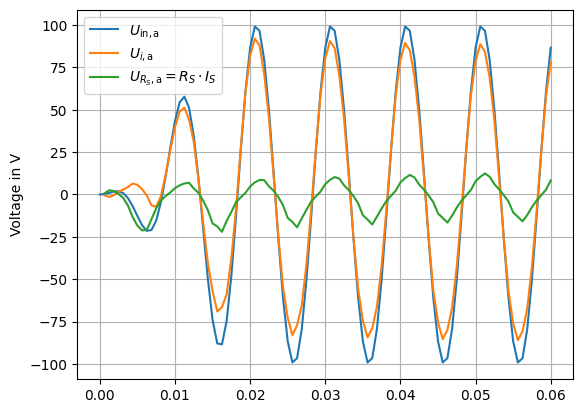

In [26]:
from matplotlib import pyplot as plt

%matplotlib inline

colors = plt.get_cmap("tab10").colors

# PLOT VOLTAGES:
fig, ax = plt.subplots()

for phase in "a":  # bc":

    # plot input voltage over winding phase
    U_in = results["voltage"][phase]
    ax.plot(results["time"], U_in, label=f"$U_\\mathrm{{in,{phase}}}$")

    # plot induced voltage
    U_emf = results["inducedVoltage"][phase]
    ax.plot(
        results["time"][1:],  # induced voltage only available in second time step
        U_emf,
        label=f"$U_{{i,\mathrm{{{phase}}}}}$",
    )

    # remaining voltage is voltage drop over R_S
    ax.plot(
        results["time"][1:],
        U_in[1:] - U_emf,
        label=f"$U_{{R_S,\\mathrm{{{phase}}}}}=R_S \\cdot I_S$",
    )
ax.set_ylabel("Voltage in V")
ax.grid(True)
_ = ax.legend()

Using the current results we can show that the phase current and the corresponding voltage drop over the resistance are in phase: 

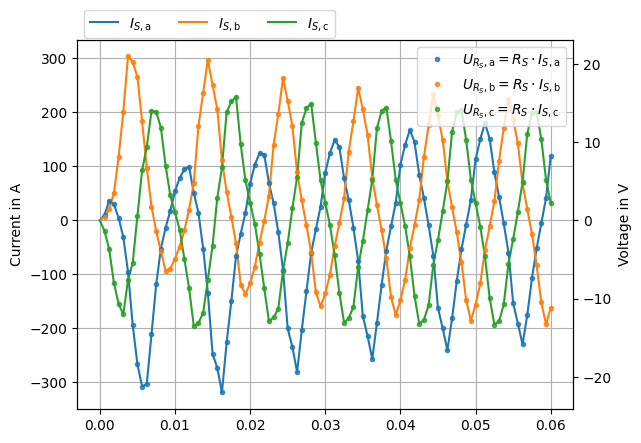

In [42]:
# PLOT CURRENT AND RS VOLTAGE DROP
fig, ax = plt.subplots()
secax = ax.twinx()
secax.set_ylabel("Voltage in V")
for i, phase in enumerate("abc"):

    # plot phase current
    I = results["current"][phase]
    ax.plot(results["time"], I, label=f"$I_{{S,\\mathrm{{{phase}}}}}$")

    # Show that remaining voltage (voltage drop over R_S) is in phase with I_S
    U_in = results["voltage"][phase]
    U_emf = results["inducedVoltage"][phase]
    secax.plot(
        results["time"][1:],
        U_in[1:] - U_emf,
        linestyle="none",
        marker=".",
        alpha=0.8,
        color=colors[i],
        label=f"$U_{{R_S,\\mathrm{{{phase}}}}}=R_S \\cdot I_{{S,\\mathrm{{{phase}}}}}$",
    )

ax.set_ylabel("Current in A")
ax.grid(True)
ax.legend(loc="upper left", bbox_to_anchor=(0.0, 1.1), ncol=3)
_ = secax.legend(loc=1)
# ax.set_xlim([results["time"][-1] - T_s, results["time"][-1]])

Finally we can have a look at the resulting torque and dq-flux results.
Due to the electrical time constant of the system $\tau = \frac{L_S}{R_S}$ we notice a settling process.
The relaxation (ramping the voltage amplitude in a quarter sine wave) helps with the stability of this settling process.

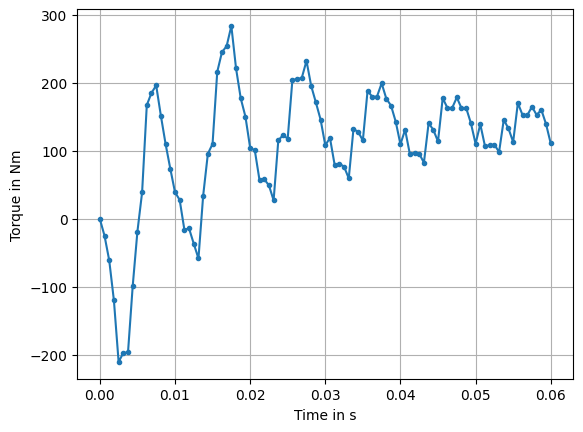

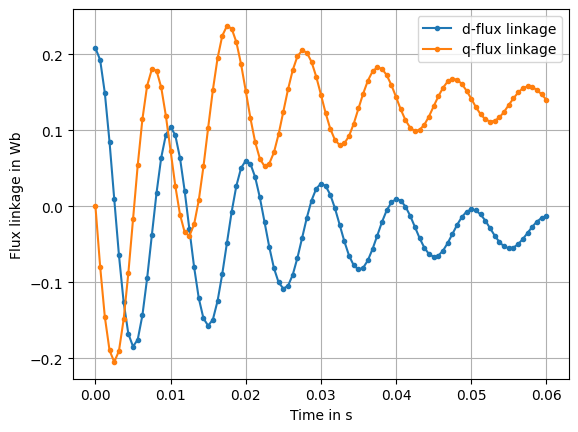

In [28]:
# Plot torque and dq flux linkage

fig, ax = plt.subplots()
ax.plot(results["time"], results["torque"], ".-")
ax.set_ylabel("Torque in Nm")
ax.set_xlabel("Time in s")
ax.grid()

fig, ax = plt.subplots()
ax.plot(results["time"], results["flux"]["d"], ".-", label="d-flux linkage")
ax.plot(results["time"], results["flux"]["q"], ".-", label="q-flux linkage")
ax.set_ylabel("Flux linkage in Wb")
ax.set_xlabel("Time in s")
ax.grid()
_ = ax.legend()